**Mythical Landmarks**

#### This project uses a dataset of figures from the *Odyssey*, the locations connected to them, coordinates for those locations, and citations for the figure-location connections.

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import folium as fm
import plotly.express as px

# read the data file and create a data frame
df = pd.read_excel('Mythical Landmark Dataset1.xlsx')

#### Sanity Checks

In [ ]:
df.head()

,Figure,Location,Stop,Description,Citation (The Odyssey Translated by Emily Wilson),Lat,Lon,Lines,Loc_type,Associated Physical Location
0,Odysseus,Troy,1,Odysseus start of his journey,"Book 1, lines 1-9",39.957500,26.238900,"Tell me about a complicated man. Muse, tell me...",Physical,Troy
1,Odysseus,Ismarus,2,Odysseus goes to the Cicones in Ismarus.,"Book 9, lines 40-43",40.960000,25.370000,A blast of wind pushed me off course towards 4...,Physical,Ismarus
2,Odysseus,Land of the Lotus-Eaters,3,Odysseys goes to the island where the Lotus-Ea...,"Book 9, lines 84-92",33.783333,10.883333,"On the tenth day, I landed on the island of th...",Mythical,Island of Djerba
3,Odysseus,The Cyclopes,4,Odysseus visits the Cyclops,"Book 9, lines 106-111",37.751800,14.994700,With heavy hearts we sailed along and reached ...,Mythical,Mount Etna
4,Odysseus,Aeolia,5,Aeolus gives Odysseus a bag of winds,"Book 10, lines 13-20",38.791700,15.213900,We arrived at that fine citadel. He welcomed m...,Mythical,Stromboli


In [ ]:
df.tail()

,Figure,Location,Stop,Description,Citation (The Odyssey Translated by Emily Wilson),Lat,Lon,Lines,Loc_type,Associated Physical Location
28,Nausicaa,Scheria,0,Odysseus wakes and sees Nausicaa,"Book 6, lines 108-118",39.62500,19.9223,So Nausicaa stood out above them all. But when...,Mythical,Corfu
29,Polyphemus,The Cyclopes,0,The home of Polyphemus,"Glossary, ""Polyphemus""",37.75180,14.9947,Polyphemus (po-li-fee´-mus): son of Poseidon a...,Mythical,Mount Etna
30,Eumaeus,Ithaca,0,"Telemachus arrives at Ithaca, at Eumaeus' home","Book 16, lines 1-22",38.42854,20.6765,At dawn the swineherd and Odysseus made breakf...,Physical,Ithaca
31,Antinous,Ithaca,0,Antinous is at Odysseus' palace,"Book 17, lines 498-507",38.42854,20.6765,"Penelope said, “Yes, dear, they are all our en...",Physical,Ithaca
32,Helen,Sparta,0,Helen is at Menelaus'' house,"Book 4, lines 119-148",37.04000,22.4300,"As he was hesitating, Helen emerged from her h...",Physical,Sparta


In [ ]:
df.shape

(33, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 10 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Figure                                             33 non-null     object 
 1   Location                                           33 non-null     object 
 2   Stop                                               33 non-null     int64  
 3   Description                                        33 non-null     object 
 4   Citation (The Odyssey Translated by Emily Wilson)  33 non-null     object 
 5   Lat                                                33 non-null     float64
 6   Lon                                                33 non-null     float64
 7   Lines                                              33 non-null     object 
 8   Loc_type                                           33 non-null     object 
 9   Associated P

In [ ]:
df.describe()

,Stop,Lat,Lon
count,33.000000,33.000000,33.000000
mean,3.484848,37.620284,19.376885
std,4.486934,5.364303,5.451361
min,0.000000,9.145000,10.883333
25%,0.000000,37.500000,14.994700
50%,1.000000,38.428540,20.476111
75%,6.000000,39.625000,21.696300
max,14.000000,41.237951,40.489700


#### Map of Locations

In [ ]:
# define the map
full_map = fm.Map(location=[df['Lat'].mean(), df['Lon'].mean()], zoom_start = 5, tiles = "CartoDB darkmatter")

# group figures into groups of same location
for loc, group in df.groupby('Location'):
    grouped_figures_by_loc = ', '.join(group['Figure'].unique())

    # create map
    fm.CircleMarker(
        location = [group['Lat'].iloc[0], group['Lon'].iloc[0]],
        radius = 5,
        fill = True,
        color = '#2288b3',
        popup = grouped_figures_by_loc,
        tooltip = loc
    ).add_to(full_map)

# display the map
full_map

#### Locations by Type

In [ ]:
# create a map colored by location type
loc_type_map = fm.Map(location=[df['Lat'].mean(), df['Lon'].mean()], zoom_start = 5, tiles = "CartoDB darkmatter")

for i, row in df.iterrows():
    if row['Loc_type'] == 'Physical':
        marker_color = '#5D3FD3'
    else:
        marker_color = '#ff3355'

    fm.CircleMarker(
        location = [row['Lat'], row['Lon']],
        radius = 5,
        color = marker_color,
        tooltip = row['Location'] + ' : ' + row['Loc_type']
    ).add_to(loc_type_map)

# display the map
loc_type_map

#### Most Common Locations

In [ ]:
# count how many figures are connected to each location
loc_count = df.groupby('Location')['Figure'].nunique().reset_index()
loc_count.rename(columns = {'Figure': 'fig_count'}, inplace = True)

# sort the values
loc_count = loc_count.sort_values('fig_count', ascending = False)
loc_count.head()

,Location,fig_count
5,Ithaca,6
11,Scheria,4
14,Sparta,3
0,Aeaea,2
8,Ogygia,2


In [ ]:
# create bar chart of most common locations
loc_fig_chart = loc_count.head(30)

fig_loc_fig_chart = px.bar(
    loc_fig_chart,
    x = 'fig_count',
    y = 'Location',
    orientation = 'h',
    title = 'Locations with Most Figures',
    text = 'fig_count'
)

fig_loc_fig_chart.update_layout(
    xaxis_title = 'Amount of Figures',
    yaxis_title = 'Location')

fig_loc_fig_chart.update_traces(marker_color = "#2288b3")
fig_loc_fig_chart.update_layout(title_x = 0.5)
fig_loc_fig_chart.update_layout(template = "plotly_dark")
fig_loc_fig_chart.update_yaxes(autorange = 'reversed')

fig_loc_fig_chart.show()

#### Figure and Location Graph

In [ ]:
# create the graph
G = nx.Graph()

for i, row in df.iterrows():
    G.add_edge(row['Figure'], row['Location'])

# print the number of vertices and edges
print(G)

Graph with 32 nodes and 32 edges


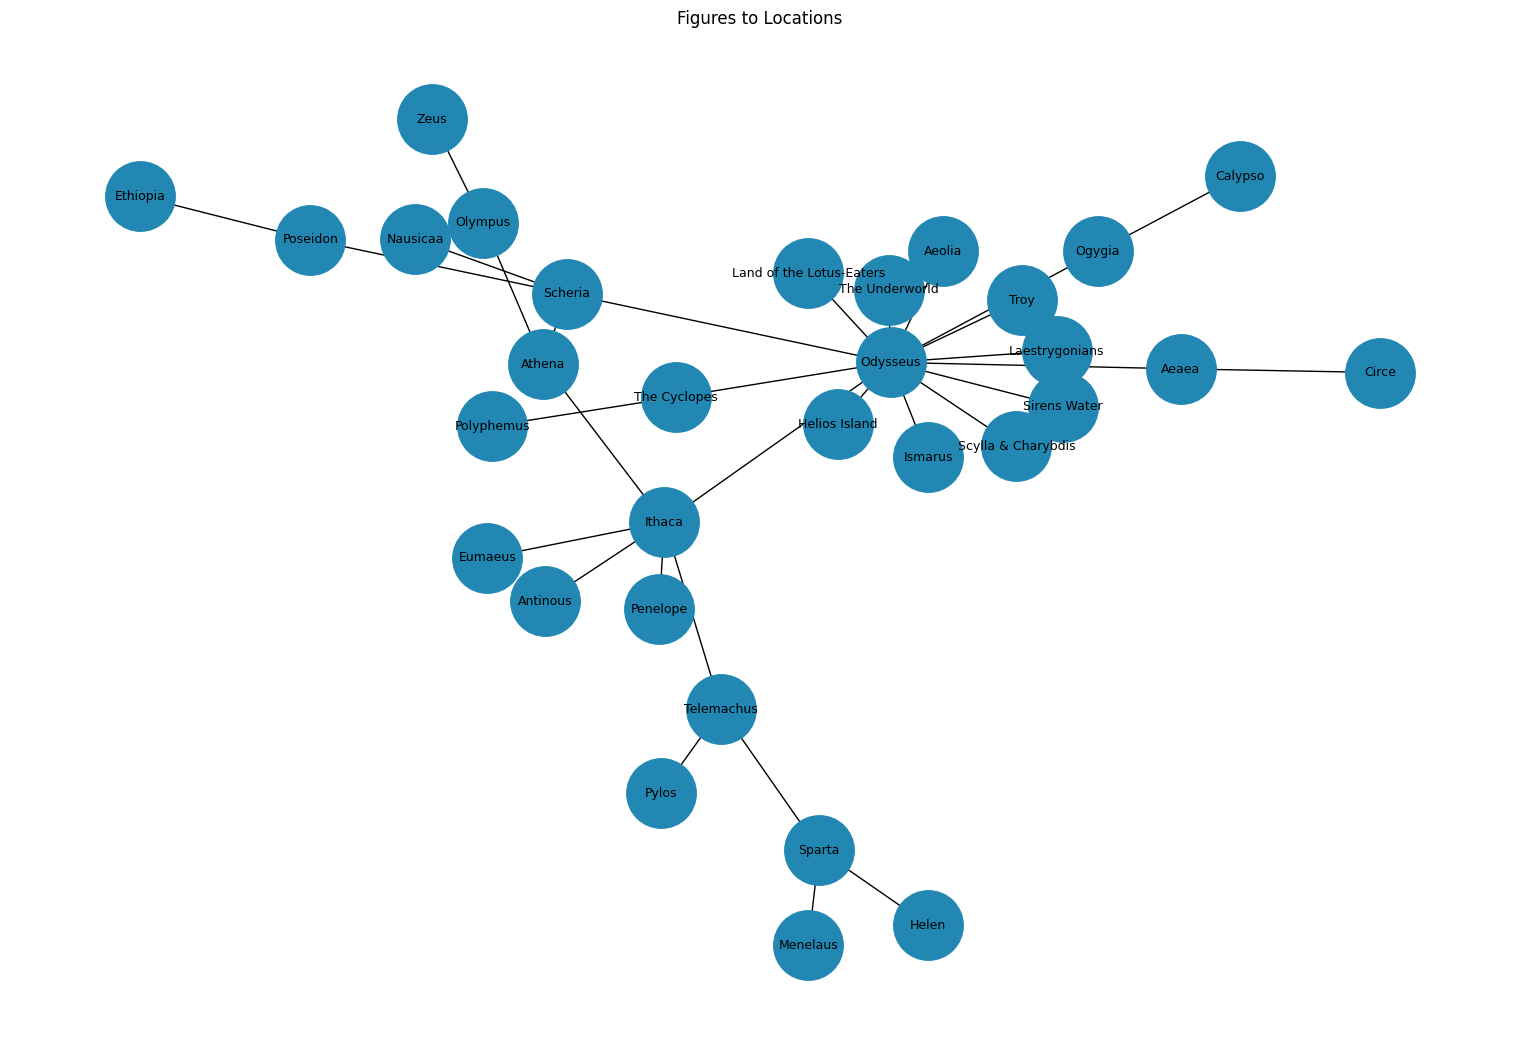

In [ ]:
# draw the graph
plt.figure(figsize = (15, 10))

pos = nx.spring_layout(G, seed = 42)

nx.draw(
    G,
    pos,
    font_size = 9,
    node_size = 2500,
    node_color = '#2288b3',
    with_labels = True
)

plt.title('Figures to Locations')
plt.show()

#### Network Graph

In [ ]:
# install PyVis
!pip install pyvis

from pyvis.network import Network

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.3 MB/s eta 0:00:00


In [ ]:
# create network graph
net = Network(
    notebook = True,
    height= 700,
    width= '100%',
    bgcolor='black',
    font_color='white',
    cdn_resources='in_line'
)

net.from_nx(G)

for node in net.nodes:
    node["color"] = "#2288b3"
    node_name = node["label"]
    degree = G.degree[node_name]
    node["size"] = 10 + degree * 5

# show the graph
net.show('network_graph.html')

network_graph.html


#### Odysseus Journey

In [ ]:
# create a dataframe of Odysseus' locations
odysseus_df = df[df['Figure'] == 'Odysseus'].copy()

# sort by in order of 'Stop'
odysseus_df = odysseus_df.sort_values('Stop')

# simple sanity check
odysseus_df.head()

,Figure,Location,Stop,Description,Citation (The Odyssey Translated by Emily Wilson),Lat,Lon,Lines,Loc_type,Associated Physical Location
0,Odysseus,Troy,1,Odysseus start of his journey,"Book 1, lines 1-9",39.957500,26.238900,"Tell me about a complicated man. Muse, tell me...",Physical,Troy
1,Odysseus,Ismarus,2,Odysseus goes to the Cicones in Ismarus.,"Book 9, lines 40-43",40.960000,25.370000,A blast of wind pushed me off course towards 4...,Physical,Ismarus
2,Odysseus,Land of the Lotus-Eaters,3,Odysseys goes to the island where the Lotus-Ea...,"Book 9, lines 84-92",33.783333,10.883333,"On the tenth day, I landed on the island of th...",Mythical,Island of Djerba
3,Odysseus,The Cyclopes,4,Odysseus visits the Cyclops,"Book 9, lines 106-111",37.751800,14.994700,With heavy hearts we sailed along and reached ...,Mythical,Mount Etna
4,Odysseus,Aeolia,5,Aeolus gives Odysseus a bag of winds,"Book 10, lines 13-20",38.791700,15.213900,We arrived at that fine citadel. He welcomed m...,Mythical,Stromboli


In [ ]:
# create a map of the journey
fig_line = px.line_mapbox(
    odysseus_df,
    lat='Lat',
    lon='Lon',
    hover_name='Location',
    text='Location',
    zoom=4.5,
    height=650,
    hover_data=["Figure", "Description"],
    color_discrete_sequence=["#2288b3"]
)

fig_line.update_layout(
    mapbox_style='carto-darkmatter')

fig_line.show()

#### Animated Journey

In [ ]:
# animated map of Odysseus' Journey
fig_anim = px.scatter_mapbox(
    odysseus_df,
    lat='Lat',
    lon='Lon',
    hover_name='Location',
    text='Location',
    animation_frame='Stop',
    zoom=3,
    height=650,
    color_discrete_sequence=["#2288b3"]
)

fig_anim.update_layout(mapbox_style='carto-darkmatter')
fig_anim.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 1500
fig_anim.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 700

fig_anim.update_traces(
    textfont=dict(color="white")
)
fig_anim.layout.updatemenus[0].font = dict(color="black")
fig_anim.show()

#### Dashboard

In [ ]:
# convert fm maps to html
landmarks_map_html = full_map._repr_html_()
loc_type_map_html = loc_type_map._repr_html_()

# get plotly graphs to html
loc_fig_chart_html = fig_loc_fig_chart.to_html(full_html=False, include_plotlyjs=False)
plotly_line_html = fig_line.to_html(full_html=False, include_plotlyjs=False)

fig_anim.write_html('odysseus_trav_animation.html', include_plotlyjs='cdn', full_html=True)

# create the dashboard
html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Mythical Landmarks</title>
    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.3/dist/leaflet.css" crossorigin=""/>
    <link href="https://fonts.googleapis.com/css2?family=Sansita:wght@400;700;800&display=swap" rel="stylesheet">
    <script src="https://unpkg.com/leaflet@1.9.3/dist/leaflet.js" crossorigin=""></script>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        body {{ font-family: Sansita, sans-serif; margin: 0; padding: 20px; background-color: #f4f4f4; color: #333; }}
        h1 {{ text-align: center; color: #2288b3; margin-bottom: 30px; }}
        .dashboard-container {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(450px, 1fr)); gap: 20px; max-width: 1400px; margin: 20px auto; }}
        .card {{ background-color: #fff; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); padding: 20px; overflow: hidden; }}
        .card h2 {{ margin-top: 0; color: #2288b3; border-bottom: 1px solid #eee; padding-bottom: 10px; margin-bottom: 15px; }}
        .card p {{margin-bottom: 12px; color: #666; font-size: 14px;}}
        .map-container {{ height: 400px; width: 100%; }}
        .plotly-graph {{ width: 100%; min-height: 520px; }}
        .plotly-map {{ width: 100%; min-height: 650px; }}
        .graph-container {{ width: 100%; height: 700px; border: none; }}
        .full-width {{ grid-column: 1 / -1; }}
    </style>
</head>
<body>
    <h1>Mythical Landmarks</h1>
    <div class="dashboard-container">

      <div class="card full-width">
            <h2>Dashboard Goal:</h2>
            <p>This dashboard uses a dataset containing information about prominent characters from the Odyssey.
            The goal is to display connections between mythological characters and locations they have visited in a fun, and interactive way. Note that mythological locations are represented using their commonly associated physical location.</p>
        </div>


        <div class="card">
            <h2>All Landmarks</h2>
            <p>Map of all landmarks. Hover over points for location name and click for character names .</p>
            <div class="map-container">
                {landmarks_map_html}
            </div>
        </div>

        <div class="card">
            <h2>Physical VS Mythological</h2>
            <p>Red points mark mythical locations & purple points marks physical locations.</p>
            <div class="map-container">
                {loc_type_map_html}
            </div>
        </div>

        <div class="card full-width">
            <h2>Locations With Most Figures</h2>
            <p>Sorted by locations that have the most associated figures.</p>
            <div class="plotly-graph">
                {loc_fig_chart_html}
            </div>
        </div>

        <div class="card full-width">
            <h2>Connecting Figures to Locations</h2>
            <p>Node graph of all figures and locations connected to them. Larger nodes have more connections. Click and drag to interact.</p>
            <iframe src="network_graph.html" class="graph-container"></iframe>
        </div>

        <div class="card full-width">
            <h2>Odysseus' Journey</h2>
            <p>Path in the order that Odysseus traveled. Hover points for more information, including descriptions. Path starts at Troy (top right).</p>
            <div class="plotly-map">
                {plotly_line_html}
            </div>
        </div>

        <div class="card full-width">
            <h2>Animation of Odysseus' Journey</h2>
            <p>Odysseus' stops individually mapped in order. Press play to view animation.</p>
            <iframe src="odysseus_trav_animation.html" class="graph-container"></iframe>
        </div>

        <div class="card full-width">
             <h2>Conclusion</h2>
             <p>The results of these visuals conclude that Odysseus, expectedly, had the most connections with each location and character.
             It is clear with the travel maps that he went back and forth many times across the area, given that the mythological locations are similar to where they would actually be.
             This aligns with how his journey was exhaustive, and on top of what he went through at every location, moving around that much is a difficult task itself.
             The location chart distinguishes three of the most connected locations: Ithaca, Scheria, and Sparta. Then it disbands into 2 groups of one and two figures per location.
             Associating that with the node graph, you can make out that Odysseus, Ithaca, Scheria, Athena, Sparta, and Telemachus were some of the more prominent characters and locations.
             You can recognize how each of those characters/locations had their own relationships with other characters/locations. The whole node graph exhibits how some characters/locations are closely tied together, while some are more distant.
             However, with context we know that even the most distant characters can have strong impacts, such as Zeus, who was a problem in Odysseus' return home. We can notice that Ethiopia is an outlier, but connects to Poseidon who was also a major issue for Odysseus.
             You can also note that Athena is one of the largest nodes, aligning with her significance in helping Odysseus.
             These visualizations do not display a complete representation however, as there are more characters and locations in the Odyssey. With more data, each node could have more connections, but with this dataset we still get a good depiction of the overarching story.</p>
        </div>
    </div>
</body>
</html>
"""

with open('mythical_landmark_dashboard.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print('Dashboard saved to mythical_landmark_dashboard.html')

Dashboard saved to mythical_landmark_dashboard.html


#### Conclusion

The results of these visuals conclude that Odysseus, expectedly, had the most connections with each location and character.
             It is clear with the travel maps that he went back and forth many times across the area, given that the mythical locations are similar to where they would actually be.
             In the node graph, you can make out that Odysseus, Ithaca, Scheria, Athena, Sparta, and Telemachus were some of the more prominent characters and locations.
             This doesn't lower the importance of all other characters and locations, but it highlights which ones were most connected.
             Overall, the graphs display an insightful view of how the Odyssey's relationships span.